In [2]:
import pandas as pd
import matplotlib.pyplot as plt


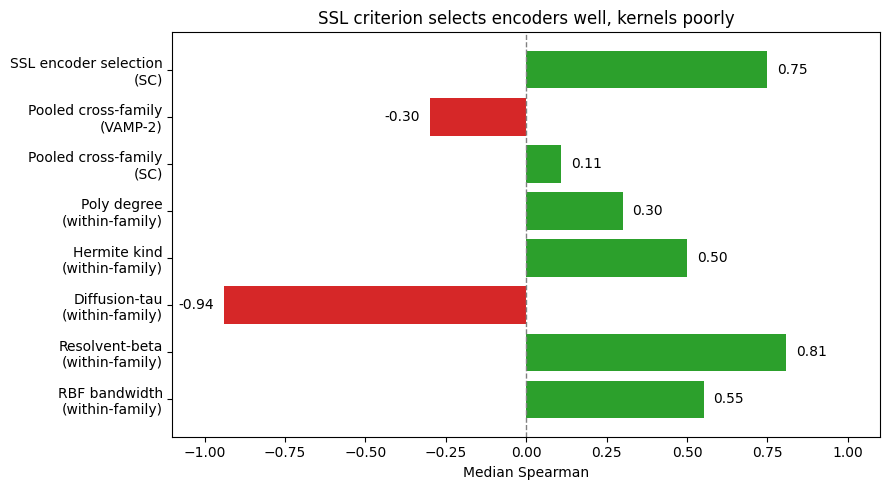

In [ ]:
df1 = pd.read_csv("pool1_sc_vamp2_selection.csv")
colors = ["#2ca02c" if v > 0 else "#d62728" for v in df1["median_spearman"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df1["pool"], df1["median_spearman"], color=colors)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Median Spearman")
ax.set_title("SSL criterion selects encoders well, kernels poorly")
ax.set_xlim(-1.1, 1.1)
for bar, val in zip(bars, df1["median_spearman"]):
    ax.text(
        val + (0.03 if val > 0 else -0.03),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        ha="left" if val > 0 else "right",
    )
plt.tight_layout()
plt.savefig("chart1_sc_vamp2_pools.png", dpi=300)
plt.show()


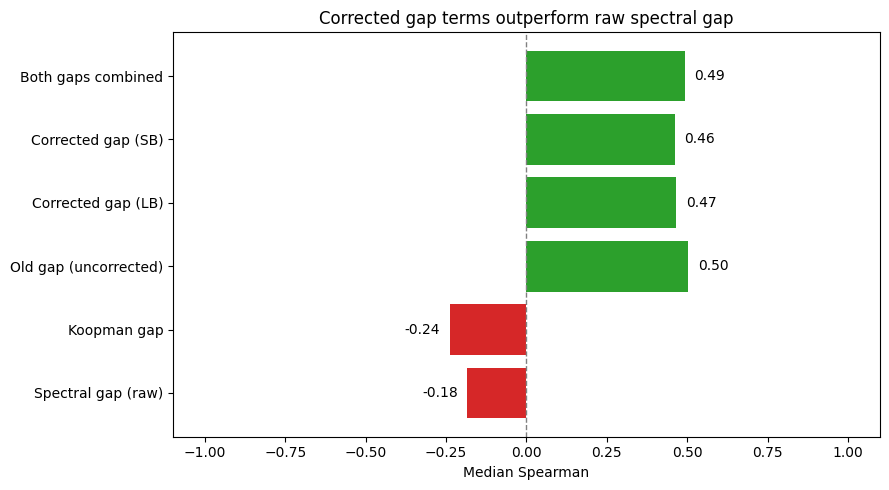

In [4]:
df2 = pd.read_csv("pool2_gap_terms_selection.csv")
colors = ["#2ca02c" if v > 0 else "#d62728" for v in df2["median_spearman"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df2["metric"], df2["median_spearman"], color=colors)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Median Spearman")
ax.set_title("Corrected gap terms outperform raw spectral gap")
ax.set_xlim(-1.1, 1.1)
for bar, val in zip(bars, df2["median_spearman"]):
    ax.text(
        val + (0.03 if val > 0 else -0.03),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        ha="left" if val > 0 else "right",
    )
plt.tight_layout()
plt.savefig("chart2_gap_terms.png", dpi=300)
plt.show()


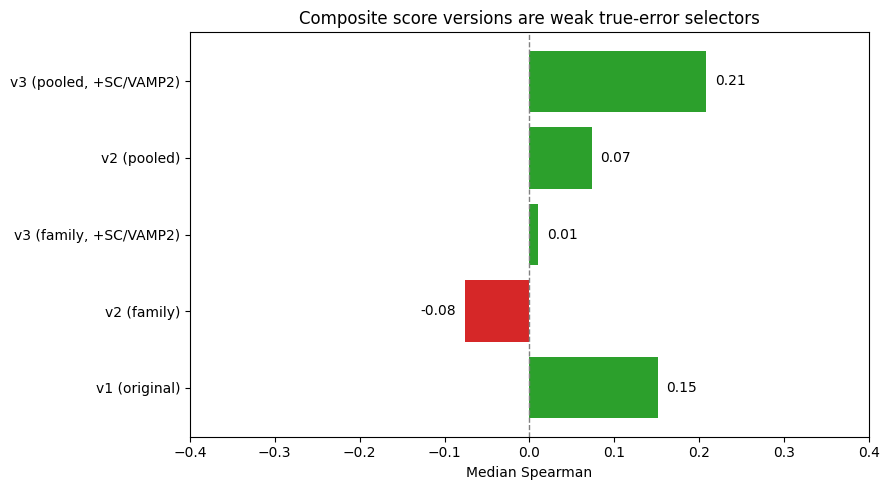

In [5]:
df3 = pd.read_csv("pool3_version_comparison.csv")
colors = ["#2ca02c" if v > 0 else "#d62728" for v in df3["median_spearman"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df3["version"], df3["median_spearman"], color=colors)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Median Spearman")
ax.set_title("Composite score versions are weak true-error selectors")
ax.set_xlim(-0.4, 0.4)
for bar, val in zip(bars, df3["median_spearman"]):
    ax.text(
        val + (0.01 if val > 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        ha="left" if val > 0 else "right",
    )
plt.tight_layout()
plt.savefig("chart3_version_comparison.png", dpi=300)
plt.show()


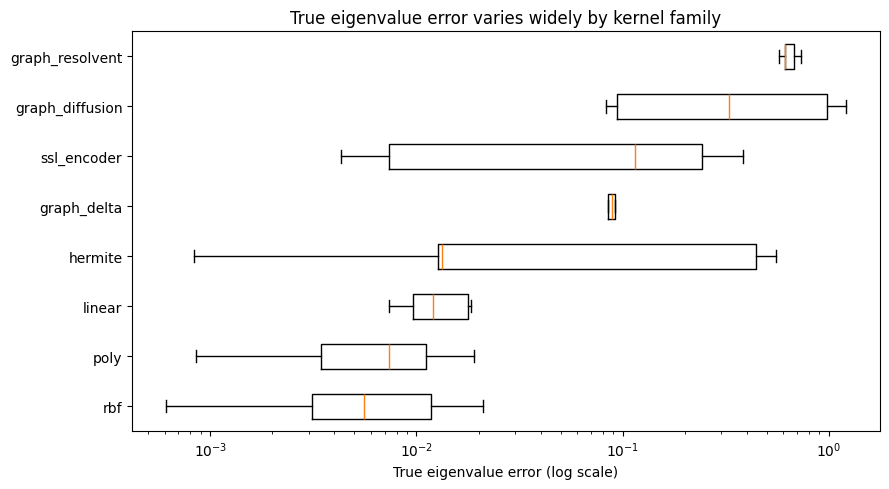

In [9]:
df4 = pd.read_csv("pool4_true_err_by_family.csv")
fam_order = df4.groupby("family")["true_eig_err"].median().sort_values().index.tolist()
data = [df4[df4.family == fam]["true_eig_err"].values for fam in fam_order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, vert=False, tick_labels=fam_order, showfliers=False)
ax.set_xscale("log")
ax.set_xlabel("True eigenvalue error (log scale)")
ax.set_title("True eigenvalue error varies widely by kernel family")
plt.tight_layout()
plt.savefig("chart4_true_err_by_family.png", dpi=300)
plt.show()


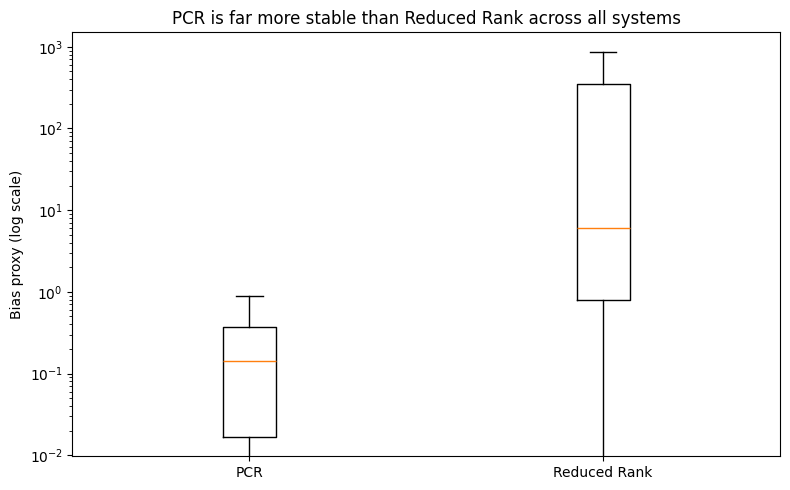

In [10]:
df5 = pd.read_csv("grand_scoring_database_v4.csv")
pcr = df5[df5.method == "PCR"]["agg_bias_mean"].dropna()
rr = df5[df5.method == "Reduced Rank"]["agg_bias_mean"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([pcr, rr], tick_labels=["PCR", "Reduced Rank"], showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("Bias proxy (log scale)")
ax.set_title("PCR is far more stable than Reduced Rank across all systems")
plt.tight_layout()
plt.savefig("chart5_pcr_vs_rr_bias.png", dpi=300)
plt.show()


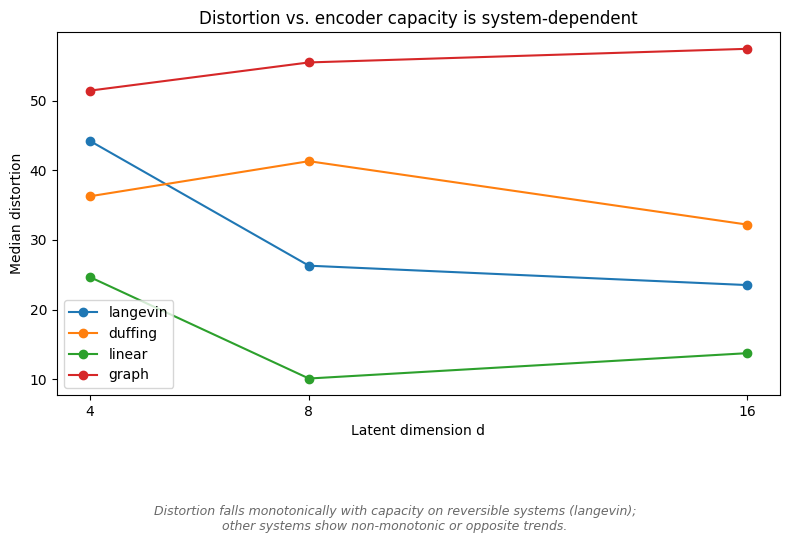

In [16]:
import re

df6 = pd.read_csv("ssl/ssl_scores.csv")
df6["d"] = df6["kernel"].str.extract(r"d=(\d+)").astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
for system in df6["system"].unique():
    sub = df6[df6.system == system].groupby("d")["agg_dist_mean"].median().sort_index()
    ax.plot(sub.index, sub.values, marker="o", label=system)
ax.set_xlabel("Latent dimension d")
ax.set_ylabel("Median distortion")
ax.set_title("Distortion vs. encoder capacity is system-dependent")
ax.set_xticks(sorted(df6["d"].unique()))
ax.legend()

fig.text(
    0.5,
    -0.02,
    "Distortion falls monotonically with capacity on reversible systems (langevin);\n"
    "other systems show non-monotonic or opposite trends.",
    ha="center",
    va="top",
    fontsize=9,
    style="italic",
    color="dimgray",
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.savefig("chart6_distortion_vs_d.png", dpi=300, bbox_inches="tight")
plt.show()
